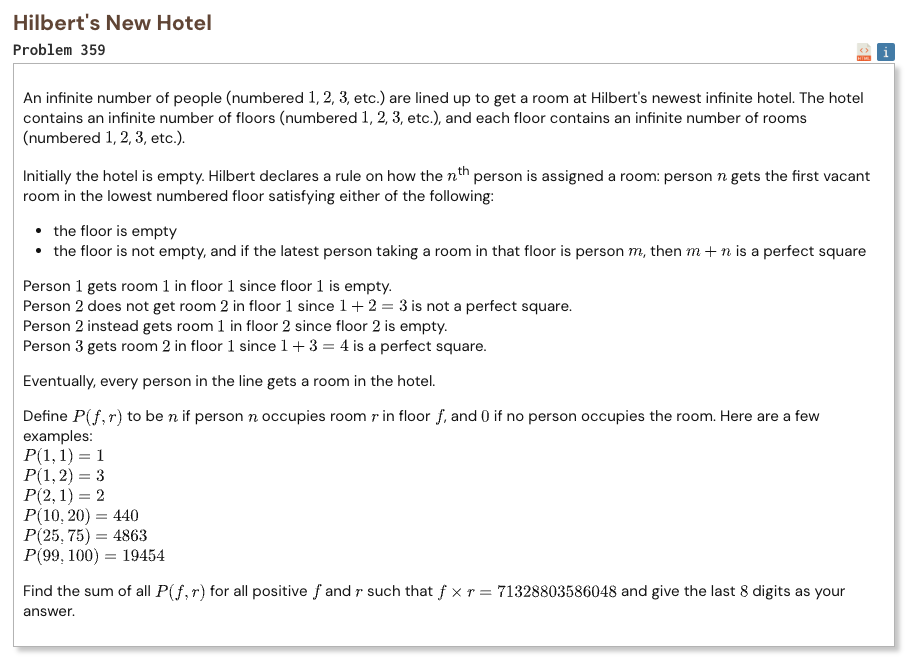

## Initial approach

* each floor follows a predictable alternating pattern
* the first room value of a floor has a simple square-based form
* after that, room values grow by alternating small and large jumps
* so P(f, r) can be computed directly without simulation
* only divisor pairs of the target number are needed
* for each divisor f, use r = target // f
* sum all P(f, r) values modulo the last eight digits

In [1]:
import math

MOD = 10 ** 8

def P(f, r):
    if f == 1:
        return r * (r + 1) // 2

    base = f * f // 2
    triangle = (r - 1) * r // 2

    if f % 2 == 0:
        return base + triangle + 2 * f * (r // 2)

    return base + triangle + (2 * f - 2) * ((r - 1) // 2)

def solve():
    target = 71328803586048
    total = 0

    for f in range(1, math.isqrt(target) + 1):
        if target % f == 0:
            r = target // f
            total = (total + P(f, r)) % MOD

            if f != r:
                total = (total + P(r, f)) % MOD

    return total

assert P(1, 1) == 1
assert P(1, 2) == 3
assert P(2, 1) == 2
assert P(10, 20) == 440
assert P(25, 75) == 4863
assert P(99, 100) == 19454

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 40632119
CPU times: user 265 ms, sys: 2.25 ms, total: 268 ms
Wall time: 267 ms
